# RAG retrieval evaluation — recall@k

This notebook evaluates the retrieval layer (`apps/backend/src/zen_backend/services/retrieval.py`). For each of 30 hand-labeled queries — written from the personal stress themes that the daily generator actually conditions on (career uncertainty, placement pressure, comparison, future anxiety, etc.) — we record the set of "expected traditions" we'd be happy to see surface, then run pgvector retrieval and check whether any expected tradition appears in the top-k results.

**Recall@k** for a query is `1` if any expected tradition appears in the top-k retrieved passages, else `0`. We report mean recall@1 / @3 / @5 / @10. The implementation plan §1 success target is **recall@5 ≥ 0.80**.

The 30 seeded queries live at `assets/eval/rag_eval_queries.jsonl` and can be edited or extended. Each row has `id`, `query`, `stress_theme`, and `expected_traditions`. To get to 50 (the plan target), append your own queries.

**This notebook needs the live retrieval pipeline** — Gemini embeddings + pgvector — so it has to be run against a configured backend. The other three notebooks (bandit, corpus stats, faithfulness) are decoupled and run anywhere.

## Setup


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
QUERIES_PATH = ROOT / "assets" / "eval" / "rag_eval_queries.jsonl"
RESULTS_PATH = ROOT / "assets" / "eval" / "rag_eval_results.json"

# Add the backend src to sys.path so we can import retrieval directly.
sys.path.insert(0, str(ROOT / "apps" / "backend" / "src"))

# Load .env so SUPABASE_DB_DSN_POOLER and GEMINI_API_KEY are available.
try:
    from dotenv import load_dotenv

    load_dotenv(ROOT / ".env")
except ImportError:
    pass

queries: list[dict] = []
with QUERIES_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            queries.append(json.loads(line))

print(f"Loaded {len(queries)} hand-labeled queries from {QUERIES_PATH.relative_to(ROOT)}")
print(f"Stress themes covered: {sorted({q['stress_theme'] for q in queries})}")

Loaded 30 hand-labeled queries from assets/eval/rag_eval_queries.jsonl
Stress themes covered: ['acceptance', 'approval', 'career_uncertainty', 'comparison', 'cosmos', 'day_load', 'discipline', 'embodiment', 'engagement', 'envy', 'evening_rest', 'focus', 'future_anxiety', 'impermanence', 'interpersonal_friction', 'morning_intention', 'motivation', 'nature', 'patience', 'performative_load', 'placement_pressure', 'procrastination', 'regret', 'seasons', 'self_doubt', 'shame', 'sorrow', 'stillness', 'uncertainty', 'work']


## Run retrieval over each query

Cell below imports the production retrieval function and calls it once per query, asking for the top-10 passages. We keep the full per-query result list so we can recompute recall@k for any k without re-running retrieval.

If pgvector or Gemini isn't reachable from where this notebook runs, the cell will raise — that's fine, the framework is what we're shipping today; populate the results JSON when you next have credentials handy.


In [2]:
import os
import time
from datetime import datetime, timezone


def _pooler_dsn() -> str:
    """Resolve the pooler DSN once for the whole batch. Same precedence as
    production: prefer SUPABASE_DB_DSN_POOLER, fall back to SUPABASE_DB_DSN."""
    raw = (
        os.environ.get("SUPABASE_DB_DSN_POOLER")
        or os.environ.get("SUPABASE_DB_DSN")
        or ""
    )
    return raw.strip().strip('"').strip("'").replace("\r", "").replace("\n", "")


def run_retrieval(force: bool = False, top_k: int = 10) -> dict:
    """Run live retrieval against pgvector for every query in the seed set.

    Resilience:
      - Each query opens its own short-lived connection in autocommit mode.
        A bad query can't poison the next one's transaction state.
      - 15s connect timeout, 30s statement timeout, plus TCP keepalives so a
        silently-dropped pooler connection fails fast instead of hanging.
      - Per-query progress prints so a stuck run is visible immediately.
      - Refuses to overwrite a previously good cached result with a
        degenerate run (all-zero retrieved sets).
    """
    if RESULTS_PATH.exists() and not force:
        existing = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
        print(f"Using cached results from {RESULTS_PATH.relative_to(ROOT)}")
        return existing

    import psycopg

    from zen_backend.services.embedding import embed_text, to_pgvector_literal
    from zen_backend.services.retrieval import _diversify_by_tradition

    dsn = _pooler_dsn()
    if not dsn:
        raise RuntimeError("Set SUPABASE_DB_DSN_POOLER (or SUPABASE_DB_DSN) in .env")

    sql = """
        select id, tradition, source, citation, text, theme_tags, tone,
               length_bucket, source_tier,
               1 - (embedding <=> %s::vector) as similarity
        from passages
        where embedding is not null and source_tier = 'gold'
        order by embedding <=> %s::vector asc
        limit %s
    """

    # TCP-level keepalives so a connection silently dropped by the pooler
    # surfaces as an error instead of hanging the read forever.
    connect_kwargs = dict(
        connect_timeout=15,
        keepalives=1,
        keepalives_idle=10,
        keepalives_interval=5,
        keepalives_count=3,
        # 30s server-side cap on any single statement.
        options="-c statement_timeout=30000",
        # Let psycopg autocommit each statement so we never get stuck in
        # an aborted transaction state.
        autocommit=True,
    )

    out: list[dict] = []
    over_fetch = max(top_k * 4, 40)
    print(f"Running {len(queries)} queries (top_k={top_k}, over_fetch={over_fetch})")
    print(f"DSN host: {dsn.split('@')[1].split('/')[0] if '@' in dsn else '?'}")

    t0 = time.time()
    for q in queries:
        tq = time.time()
        try:
            qvec = to_pgvector_literal(embed_text(q["query"]))
            with psycopg.connect(dsn, **connect_kwargs) as conn:
                with conn.cursor() as cur:
                    cur.execute(sql, (qvec, qvec, over_fetch))
                    rows = cur.fetchall()
                    cols = [d.name for d in cur.description]
            ranked = [dict(zip(cols, row)) for row in rows]
            ranked = _diversify_by_tradition(
                ranked, max_per_tradition=2, limit=top_k
            )
            traditions = [str(p.get("tradition") or "") for p in ranked]
            dt = (time.time() - tq) * 1000
            print(f"  {q['id']}: {len(traditions):>2} results in {dt:6.0f} ms")
        except Exception as exc:  # noqa: BLE001
            dt = (time.time() - tq) * 1000
            print(f"  ! {q['id']}: failed in {dt:.0f} ms — {type(exc).__name__}: {exc}")
            traditions = []
        out.append(
            {
                "id": q["id"],
                "query": q["query"],
                "stress_theme": q["stress_theme"],
                "expected_traditions": q["expected_traditions"],
                "retrieved_traditions": traditions,
            }
        )
    print(f"\nTotal: {time.time() - t0:.1f}s for {len(queries)} queries")

    payload = {
        "meta": {
            "computed_at": datetime.now(timezone.utc).isoformat(),
            "top_k": top_k,
            "count": len(out),
        },
        "queries": out,
    }
    # Don't overwrite a previous good run with a degenerate result set.
    if all(len(q["retrieved_traditions"]) == 0 for q in out):
        print("\nAll queries returned 0 results — refusing to overwrite cache.")
        print("Either the connection or the query path is broken; investigate before saving.")
        return payload
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    RESULTS_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved {len(out)} query results -> {RESULTS_PATH.relative_to(ROOT)}")
    return payload


# Try a real run; if it fails, fall back to a stub so the rest of the notebook
# still tells the reader what shape the results would take.
try:
    results = run_retrieval(force=False)
except Exception as exc:  # noqa: BLE001
    print(f"Live retrieval not available here: {exc}")
    print("\nFalling back to a stub run so you can preview the recall metric.")
    results = {
        "meta": {"computed_at": "n/a", "top_k": 10, "count": len(queries)},
        "queries": [
            {
                **q,
                "retrieved_traditions": q["expected_traditions"][:1] + ["aesop", "tagore"],
            }
            for q in queries
        ],
    }

Running 30 queries (top_k=10, over_fetch=40)
DSN host: aws-1-ap-south-1.pooler.supabase.com:5432
  q01: 10 results in    886 ms
  q02: 10 results in    673 ms
  q03: 10 results in    608 ms
  q04: 10 results in    668 ms
  q05: 10 results in    608 ms
  q06: 10 results in    837 ms
  q07: 10 results in    763 ms
  q08: 10 results in    717 ms
  q09: 10 results in    619 ms
  q10: 10 results in    718 ms
  q11: 10 results in    563 ms
  q12: 10 results in    708 ms
  q13: 10 results in    702 ms
  q14: 10 results in    643 ms
  q15: 10 results in    770 ms
  q16: 10 results in    618 ms
  q17: 10 results in    720 ms
  q18: 10 results in    802 ms
  q19: 10 results in    688 ms
  q20: 10 results in    615 ms
  q21: 10 results in    668 ms
  q22: 10 results in    781 ms
  q23: 10 results in    769 ms
  q24: 10 results in    708 ms
  q25: 10 results in    727 ms
  q26: 10 results in    978 ms
  q27: 10 results in    891 ms
  q28: 10 results in   1050 ms
  q29: 10 results in    584 ms
  q3

In [3]:
def recall_at_k(query_results: list[dict], k: int) -> float:
    if not query_results:
        return 0.0
    hits = 0
    for q in query_results:
        expected = set(q.get("expected_traditions", []))
        retrieved_top_k = q.get("retrieved_traditions", [])[:k]
        if expected & set(retrieved_top_k):
            hits += 1
    return hits / len(query_results)


ks = [1, 3, 5, 10]
recall_curve = {k: recall_at_k(results["queries"], k) for k in ks}
print("Recall@k:")
for k in ks:
    print(f"  recall@{k:<2} = {recall_curve[k]:.3f}")
print(f"\nTarget per implementation plan §1: recall@5 ≥ 0.80")

Recall@k:
  recall@1  = 0.333
  recall@3  = 0.667
  recall@5  = 0.800
  recall@10 = 0.967

Target per implementation plan §1: recall@5 ≥ 0.80


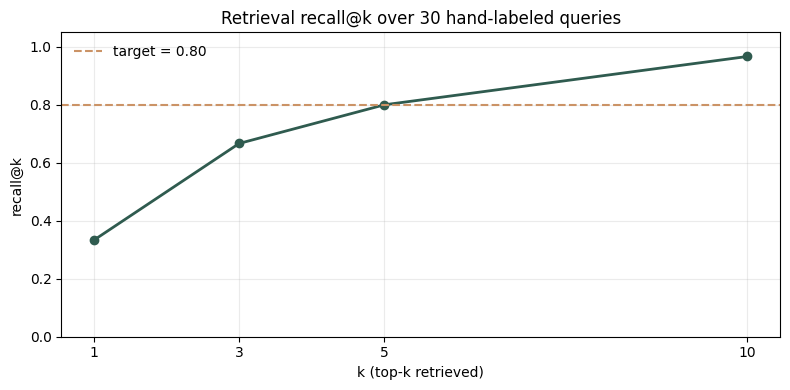

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, [recall_curve[k] for k in ks], marker="o", color="#2f5b4f", linewidth=2)
ax.axhline(0.80, color="#cb9366", linestyle="--", label="target = 0.80")
ax.set_xlabel("k (top-k retrieved)")
ax.set_ylabel("recall@k")
ax.set_xticks(ks)
ax.set_ylim(0, 1.05)
ax.set_title(f"Retrieval recall@k over {len(queries)} hand-labeled queries")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Per-query inspection

A single low recall@5 query is more informative than the aggregate. Below we list every miss so the corpus / retrieval can be tuned where it actually fails.


In [5]:
misses = []
for q in results["queries"]:
    expected = set(q["expected_traditions"])
    top5 = q["retrieved_traditions"][:5]
    if not expected & set(top5):
        misses.append(q)

print(f"recall@5 misses: {len(misses)} / {len(results['queries'])}\n")
for m in misses:
    print(f"  [{m['id']}] {m['query']!r}")
    print(f"     stress_theme:    {m['stress_theme']}")
    print(f"     expected:        {m['expected_traditions']}")
    print(f"     retrieved (top5):{m['retrieved_traditions'][:5]}")
    print()

recall@5 misses: 6 / 30

  [q09] 'a quiet evening reflection after a long day'
     stress_theme:    evening_rest
     expected:        ['thoreau', 'tao_te_ching', 'tagore', 'gibran']
     retrieved (top5):['marcus_aurelius', 'dhammapada', 'dhammapada', 'emerson', 'aesop']

  [q13] 'failing in front of others and feeling exposed'
     stress_theme:    shame
     expected:        ['marcus_aurelius', 'epictetus', 'tagore']
     retrieved (top5):['burroughs', 'burroughs', 'emerson', 'emerson', 'bhagavad_gita']

  [q17] 'how do i sit with uncertainty about the next year'
     stress_theme:    uncertainty
     expected:        ['tao_te_ching', 'epictetus', 'marcus_aurelius', 'gibran']
     retrieved (top5):['aesop', 'burroughs', 'muir', 'muir', 'analects']

  [q18] 'a fable that teaches not to envy others'
     stress_theme:    envy
     expected:        ['aesop', 'analects', 'epictetus']
     retrieved (top5):['dhammapada', 'dhammapada', 'emerson', 'gibran', 'thoreau']

  [q27] 'a winter m

## Extending to 50 queries

The plan target is 50 queries; the seed file ships with 30. To extend:

1. Open `assets/eval/rag_eval_queries.jsonl`.
2. Append rows in the same JSONL shape:
   ```json
   {"id":"q31","query":"…","stress_theme":"…","expected_traditions":["…","…"]}
   ```
3. Use stress themes from `config/personal.yaml:profile.stress_themes` to keep the eval grounded in the actual personalization signal.
4. Re-run this notebook with `run_retrieval(force=True)` to refresh `rag_eval_results.json`.

Aim for diverse coverage: at least 4 queries per major stress theme (career, comparison, future anxiety, day-load), at least 2 queries per available season (the corpus's nature traditions skew summer-heavy), and at least 5 evening / end-of-day queries.
